# Exercise: Classify Flowers with a Decision Tree

In this exercise, we'll classify three different iris flower types using a decision tree classifier. 

Your tasks are the following:

- Identify the data types of `X` and `y`
- Get an overview of the dataset
- Plot a histogram of the data
- Split into training and test data
- Examine the shape of your training data
- Train a decision tree
- Make predictions with your model
- Calculate the accuracy

## 1. Data Analysis

In [1]:
# import packages
import numpy as np 
import sklearn 
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# load data
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [3]:
# store features and labels in X and y
X = iris.data
y = iris.target

In [4]:
# print description of dataset
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

**TODO**: Which data types are X and y, respectively?

In [5]:
# TODO: YOUR CODE GOES HERE
print("Data type of X:\n")
X.info()
print("=="*20)
print("Data type of y:")
y.info()

Data type of X:

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
Data type of y:
<class 'pandas.Series'>
RangeIndex: 150 entries, 0 to 149
Series name: target
Non-Null Count  Dtype
--------------  -----
150 non-null    int64
dtypes: int64(1)
memory usage: 1.3 KB


**YOUR ANSWER**: X is a pandas DataFrame with sepal and petal measurements as columns as float64, and y is a pandas Series with the target labels as integers.

**TODO**: Get an overview of the dataset and answer the following questions:
- How many features are in the dataset?
- How many samples are in the dataset?
- Which labels do exist?
- Are there empty data entries that we have to take care of?
- Are there categorical or numerical attributes?

In [6]:
# TODO: YOUR CODE GOES HERE
X.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
y.describe()

count    150.000000
mean       1.000000
std        0.819232
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max        2.000000
Name: target, dtype: float64

**YOUR ANSWER**:

- There are 4 features in the dataset: sepal length, sepal width, petal length, and petal width.
- There are 150 samples in the dataset.
- There are 3 labels in the dataset, corresponding to the three different iris flower types: Setosa, Versicolor, and Virginica.
- There are no empty data entries in the dataset.
- All features are numerical attributes, and the target labels are categorical.

**TODO**: Plot a histogram of the data. Can you guess which features might be more important than others?

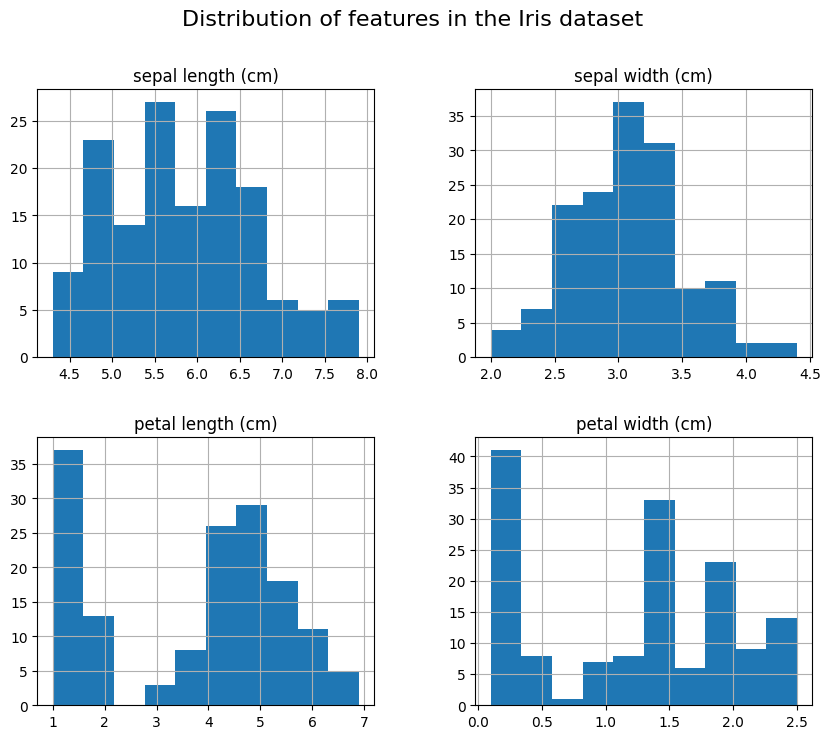

In [8]:
# TODO: YOUR CODE GOES HERE
X.hist(figsize=(10, 8))
plt.suptitle("Distribution of features in the Iris dataset", fontsize=16)
plt.show()

**YOUR ANSWER**: The petal length and petal width features seem to be more important for distinguishing between the different iris flower types, as they show more distinct distributions that could help separate the classes. The sepal length and sepal width features appear to have more overlapping distributions, which may make them less useful for classification.

# 2. Training and Evaluation

In [9]:
# we only use 2 features for training
X = iris.data[["petal length (cm)", "petal width (cm)"]]

**TODO**: Split `X` and `y` in training and test data. Save the result in variables called `X_train`, `X_test`, `y_train`, `y_test`. 

In [10]:
# TODO: YOUR CODE GOES HERE
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.3, random_state=42)

**TODO**: How many samples are contained in `X_test`? Which data format do we have here?

In [11]:
# TODO: YOUR CODE GOES HERE
X_test.info()

<class 'pandas.DataFrame'>
Index: 45 entries, 73 to 10
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   petal length (cm)  45 non-null     float64
 1   petal width (cm)   45 non-null     float64
dtypes: float64(2)
memory usage: 1.1 KB


**YOUR ANSWER**: In X_test, there are 45 samples, which corresponds to 30% of the original dataset. The data format is a pandas DataFrame for X_test with float64 data types for the features.

**TODO**: Fit a `DecisionTreeClassifier` with `max_depth=3` and `random_state` set to a value of your choice on the training data!

In [12]:
# TODO: YOUR CODE GOES HERE
model = sklearn.tree.DecisionTreeClassifier(max_depth=3, random_state=17)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",17
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

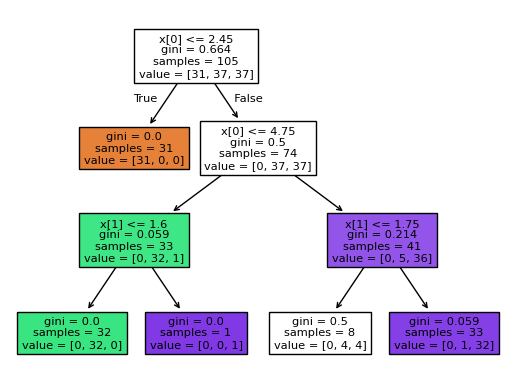

In [13]:
sklearn.tree.plot_tree(model, filled=True)
plt.show()

**TODO**: Calculate the predictions on training and test data and save the result in `y_pred_train` and `y_pred_test`, respectively.

In [14]:
# TODO: YOUR CODE GOES HERE
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

**TODO**: Evaluate your model by calculating the accuracy on training and test data, i.e. the number of correctly classified samples normalized over all samples:

$
\text{Accuracy} = \frac{\text{\# correctly classified samples}}{\text{\# samples}}
$

In [15]:
# TODO: YOUR CODE GOES HERE
accuracy_train = sklearn.metrics.accuracy_score(y_train, y_pred_train)
accuracy_test = sklearn.metrics.accuracy_score(y_test, y_pred_test)

print(f"Training accuracy: {accuracy_train:.2f}")
print(f"Testing accuracy: {accuracy_test:.2f}")

Training accuracy: 0.95
Testing accuracy: 1.00


tree thresholds: [ 2.44999999 -2.         -2.        ]
tree thresholds: [ 2.44999999 -2.          4.75       -2.         -2.        ]
tree thresholds: [ 2.44999999 -2.          4.75        1.60000002 -2.         -2.
  1.75       -2.         -2.        ]


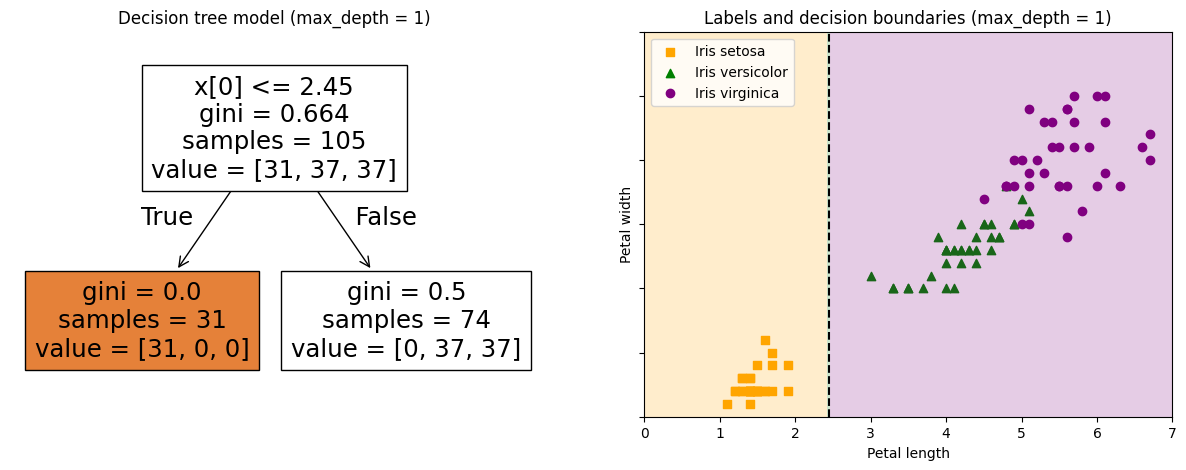

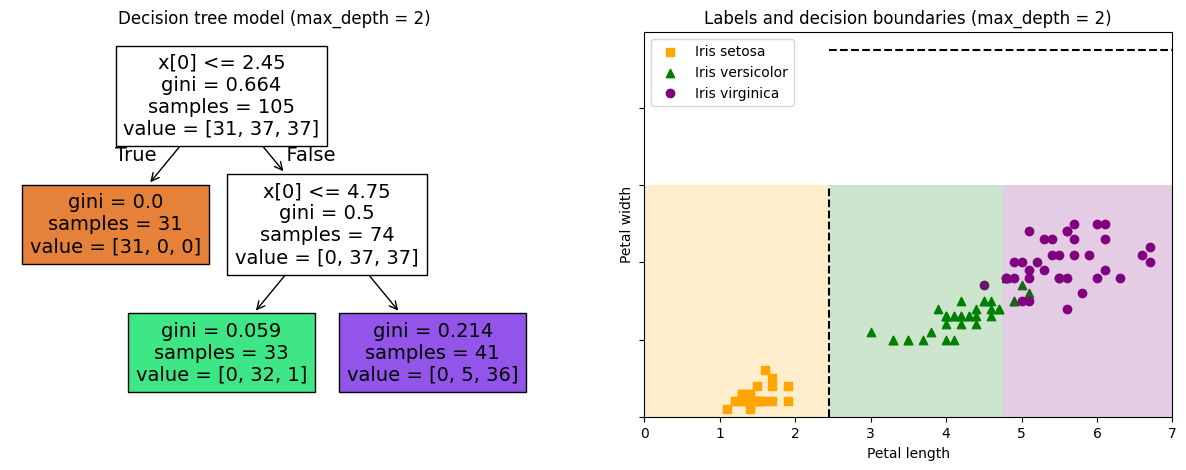

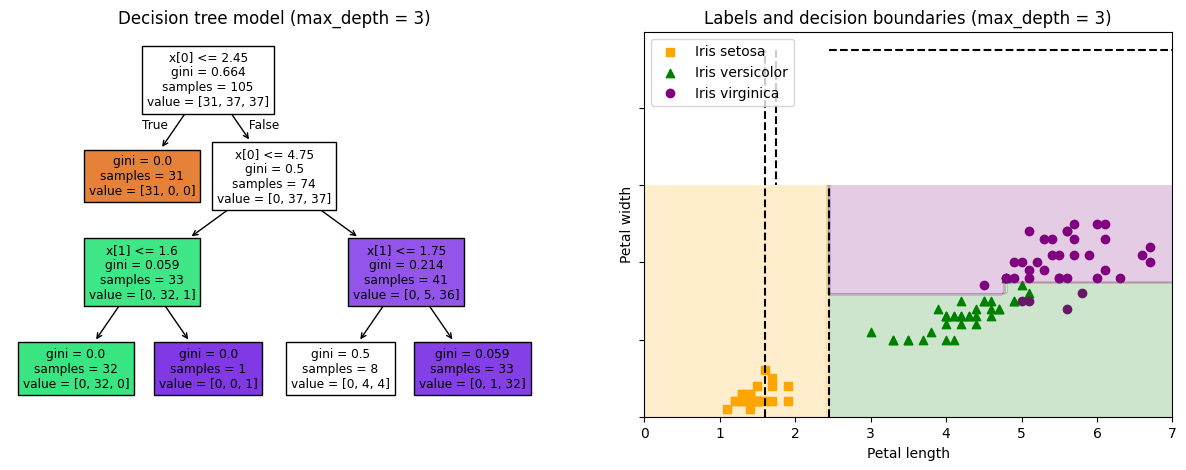

In [17]:
# plot several decision trees with different max_depth

def plot_decision_boundaries(X_train, y_train, max_depth):
    # train another decision tree classifier with variable max_depth for plotting
    model = sklearn.tree.DecisionTreeClassifier(max_depth=max_depth, random_state=13)
    model.fit(X_train.values, y_train.values)

    # use subplots to plot the decision tree and the decision boundaries
    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(15, 5))

    # plot the decision tree
    sklearn.tree.plot_tree(model, filled=True, ax=ax1)
    ax1.set_title("Decision tree model (max_depth = {})".format(max_depth))

    # plot params
    xlim0, xlim1 = 0, 7
    ylim0, ylim1 = 0, 3

    # plot labels
    ax2.scatter(X_train.values[y_train.values == 0, 0], X_train.values[y_train.values == 0, 1], color='orange', marker='s', label="Iris setosa")
    ax2.scatter(X_train.values[y_train.values == 1, 0], X_train.values[y_train.values == 1, 1], color='green', marker='^', label="Iris versicolor")
    ax2.scatter(X_train.values[y_train.values == 2, 0], X_train.values[y_train.values == 2, 1], color='purple', marker='o', label="Iris virginica")
    ax2.set_xlabel("Petal length")
    ax2.set_ylabel("Petal width")
    ax2.legend(loc="upper left")
    ax2.set_title("Labels and decision boundaries (max_depth = {})".format(max_depth))

    # plot the predictions
    from matplotlib.colors import ListedColormap
    my_cmap = ListedColormap(['orange', 'green', 'purple'])
    xx, yy = np.meshgrid(np.linspace(xlim0, xlim1, 100), np.linspace(ylim0, ylim1, 100))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, alpha=0.2, cmap=my_cmap)

    # plot the decision boundaries
    print("tree thresholds:", model.tree_.threshold)
    if max_depth == 1:
        a = model.tree_.threshold[[0]]
        ax2.plot([a, a], [ylim0, ylim1], "k--")
    elif max_depth == 2:
        a, b = model.tree_.threshold[[0, 2]]
        ax2.plot([a, a], [ylim0, ylim1], "k--")
        ax2.plot([a, xlim1], [b, b], "k--")
    elif max_depth == 3:
        a, b, c, d = model.tree_.threshold[[0, 2, 3, 6]]
        ax2.plot([a, a], [ylim0, ylim1], "k--")
        ax2.plot([a, xlim1], [b, b], "k--")
        ax2.plot([c, c], [ylim0, b], "k--")
        ax2.plot([d, d], [b, ylim1], "k--")


for i in range(1, 4):
    plot_decision_boundaries(X_train, y_train, i)